In [ ]:
pip install pandas-gbq

# **Import Library**

In [1]:
import pandas_gbq
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# **Data Loading**



> **funnel_session Data**



In [2]:
from pandas_gbq import read_gbq

project_id = "funnel-and-conversion-analysis"

query_funnel = """
SELECT *
FROM `funnel-and-conversion-analysis.processed.funnel_session`
"""

df_funnel = read_gbq(query_funnel, project_id=project_id)

Downloading: 100%|██████████|




> **product_performance Data**



In [3]:
from pandas_gbq import read_gbq

project_id = "funnel-and-conversion-analysis"

query_product_perf = """
SELECT *
FROM `funnel-and-conversion-analysis.processed.product_performance`
"""

df_product_perf = read_gbq(query_product_perf, project_id=project_id)

Downloading: 100%|██████████|




> **product_summary_count Data**



In [4]:
from pandas_gbq import read_gbq

project_id = "funnel-and-conversion-analysis"

query_product_sc = """
SELECT *
FROM `funnel-and-conversion-analysis.processed.product_summary_count`
"""

df_product_sc = read_gbq(query_product_sc, project_id=project_id)

Downloading: 100%|██████████|




> **product_summary_funnel Data**



In [5]:
from pandas_gbq import read_gbq

project_id = "funnel-and-conversion-analysis"

query_product_sf = """
SELECT *
FROM `funnel-and-conversion-analysis.processed.product_summary_funnel`
"""

df_product_sf = read_gbq(query_product_sf, project_id=project_id)

Downloading: 100%|██████████|


# **Exploratory Data Analysis (EDA)**

In [ ]:
def quick_eda(df: pd.DataFrame, name: str = "DataFrame"):
    print(f"\n===== {name} =====")

    # shape
    print("\nShape:")
    print(df.shape)

    # info
    print("\nInfo:")
    print(df.info())

    # missing values
    print("\nMissing Values (%):")
    display((df.isnull().mean() * 100).sort_values(ascending=False))

    # duplicates
    print("\nDuplicate Rows:")
    print(df.duplicated().sum())



> **EDA Funnel Session**



In [ ]:
quick_eda(df_funnel, "Funnel Session")


===== Funnel Session =====

Shape:
(884878, 10)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884878 entries, 0 to 884877
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   visitId         884878 non-null  Int64 
 1   fullVisitorId   884878 non-null  object
 2   visit_date      884878 non-null  dbdate
 3   country         884878 non-null  object
 4   device          884878 non-null  object
 5   traffic_source  884878 non-null  object
 6   product_view    884878 non-null  Int64 
 7   add_to_cart     884878 non-null  Int64 
 8   checkout        884878 non-null  Int64 
 9   purchase        884878 non-null  Int64 
dtypes: Int64(5), dbdate(1), object(4)
memory usage: 71.7+ MB
None

Missing Values (%):


,0
visitId,0.0
fullVisitorId,0.0
visit_date,0.0
country,0.0
device,0.0
traffic_source,0.0
product_view,0.0
add_to_cart,0.0
checkout,0.0
purchase,0.0



Duplicate Rows:
0


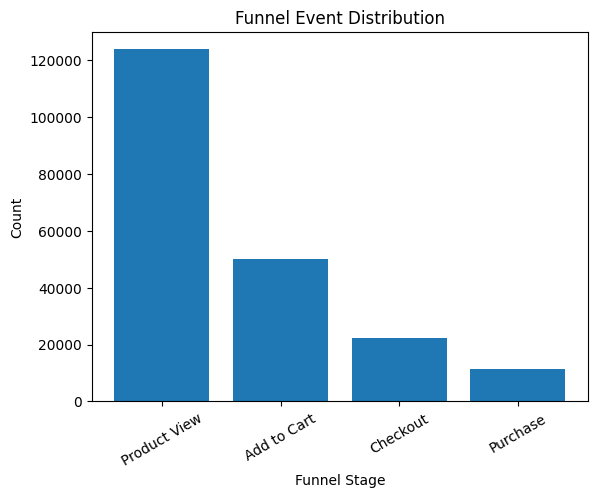

In [6]:
# Funnel Event Distribution
funnel_counts = {
    'Product View': df_funnel['product_view'].sum(),
    'Add to Cart': df_funnel['add_to_cart'].sum(),
    'Checkout': df_funnel['checkout'].sum(),
    'Purchase': df_funnel['purchase'].sum()
}

funnel_df = pd.DataFrame(list(funnel_counts.items()), columns=['Stage', 'Count'])

# Plot
plt.figure()
plt.bar(funnel_df['Stage'], funnel_df['Count'])
plt.title('Funnel Event Distribution')
plt.xlabel('Funnel Stage')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()



> **EDA Product Performance**



In [ ]:
quick_eda(df_product_perf, "Product Performance")


===== Product Performance =====

Shape:
(33244, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33244 entries, 0 to 33243
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   visitId        33244 non-null  Int64 
 1   fullVisitorId  33244 non-null  object
 2   visit_date     33244 non-null  dbdate
 3   country        33244 non-null  object
 4   device         33244 non-null  object
 5   product_name   33244 non-null  object
 6   is_purchase    33244 non-null  Int64 
dtypes: Int64(2), dbdate(1), object(4)
memory usage: 1.8+ MB
None

Missing Values (%):


,0
visitId,0.0
fullVisitorId,0.0
visit_date,0.0
country,0.0
device,0.0
product_name,0.0
is_purchase,0.0



Duplicate Rows:
0


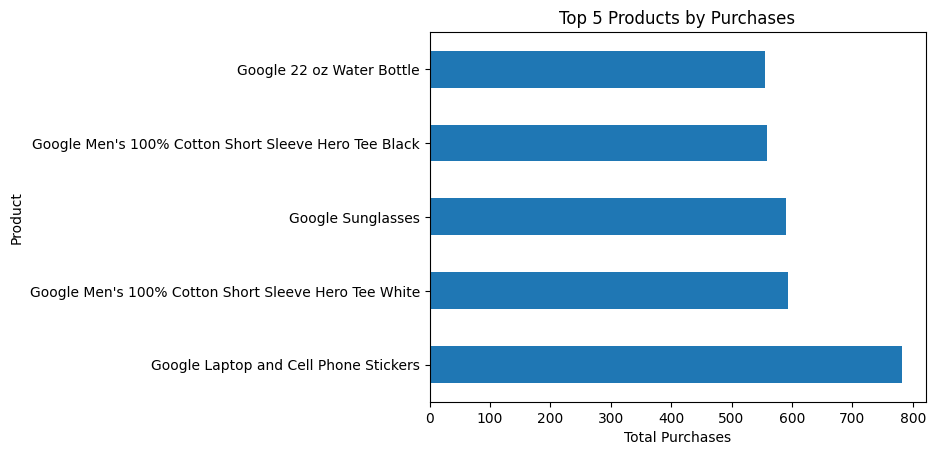

In [8]:
# Top 5 Products by Purchases
top_products = (
    df_product_perf
    .groupby('product_name')['is_purchase']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure()
top_products.plot(kind='barh')
plt.title('Top 5 Products by Purchases')
plt.xlabel('Total Purchases')
plt.ylabel('Product')
plt.show()



> **EDA Product Summary Count**



In [ ]:
quick_eda(df_product_sc, "Product Summary Count")


===== Product Summary Count =====

Shape:
(621, 6)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621 entries, 0 to 620
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product_name    621 non-null    object
 1   total_sessions  621 non-null    Int64 
 2   product_view    621 non-null    Int64 
 3   add_to_cart     621 non-null    Int64 
 4   checkout        621 non-null    Int64 
 5   purchase        621 non-null    Int64 
dtypes: Int64(5), object(1)
memory usage: 32.3+ KB
None

Missing Values (%):


,0
product_name,0.0
total_sessions,0.0
product_view,0.0
add_to_cart,0.0
checkout,0.0
purchase,0.0



Duplicate Rows:
0


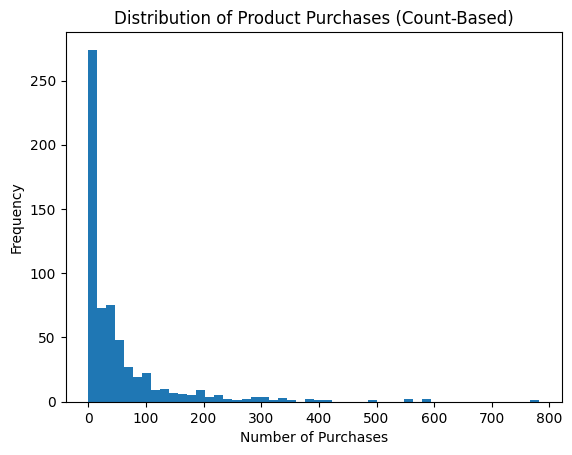

In [9]:
# Distribution of Product Purchases (Count-Based)
plt.figure()
plt.hist(df_product_sc['purchase'], bins=50)
plt.title('Distribution of Product Purchases (Count-Based)')
plt.xlabel('Number of Purchases')
plt.ylabel('Frequency')
plt.show()



> **EDA Product Summary Funnel**



In [ ]:
quick_eda(df_product_sf, "Product Summary Funnel")


===== Product Summary Funnel =====

Shape:
(621, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621 entries, 0 to 620
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   product_name               621 non-null    object 
 1   product_view               621 non-null    Int64  
 2   add_to_cart                621 non-null    Int64  
 3   checkout                   621 non-null    Int64  
 4   purchase                   621 non-null    Int64  
 5   view_to_cart_rate          493 non-null    float64
 6   cart_to_checkout_rate      485 non-null    float64
 7   checkout_to_purchase_rate  452 non-null    float64
 8   overall_conversion_rate    493 non-null    float64
dtypes: Int64(4), float64(4), object(1)
memory usage: 46.2+ KB
None

Missing Values (%):


,0
checkout_to_purchase_rate,27.214171
cart_to_checkout_rate,21.900161
overall_conversion_rate,20.611916
view_to_cart_rate,20.611916
product_name,0.000000
purchase,0.000000
checkout,0.000000
add_to_cart,0.000000
product_view,0.000000



Duplicate Rows:
0


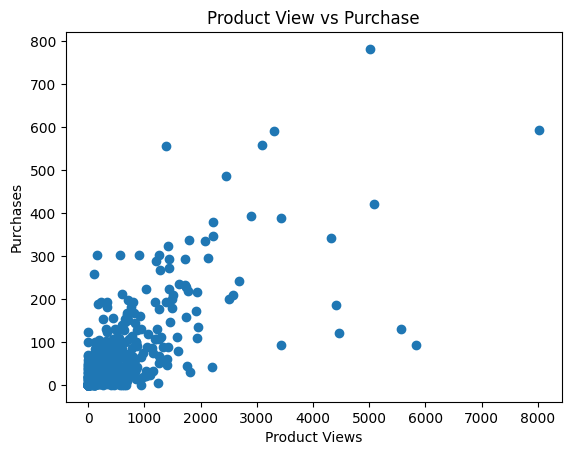

In [10]:
# Product View vs Purchase
df_product_sf_filtered = df_product_sf[
    df_product_sf['product_view'] < df_product_sf['product_view'].quantile(0.99)
] # Remove extreme outliers
plt.figure()
plt.scatter(
    df_product_sf['product_view'],
    df_product_sf['purchase']
)

plt.title('Product View vs Purchase')
plt.xlabel('Product Views')
plt.ylabel('Purchases')
plt.show()

# **Data Analysis**



> **Funnel Conversion Analysis**



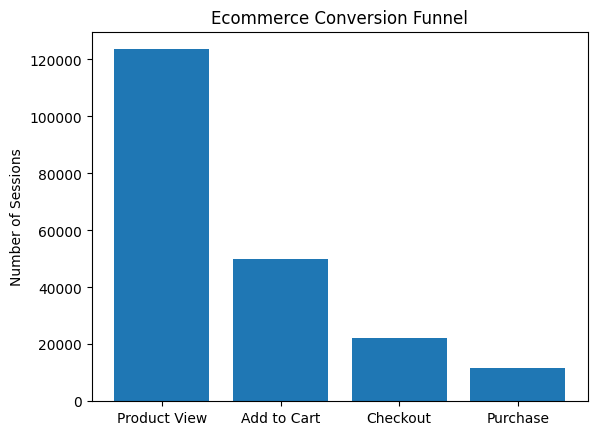

In [ ]:
# Session per Step
funnel = {
    "Product View": df_funnel['product_view'].sum(),
    "Add to Cart": df_funnel['add_to_cart'].sum(),
    "Checkout": df_funnel['checkout'].sum(),
    "Purchase": df_funnel['purchase'].sum()
}
funnel_df = pd.DataFrame(list(funnel.items()), columns=['step','sessions'])
funnel_df

plt.bar(funnel_df['step'], funnel_df['sessions'])
plt.title("Ecommerce Conversion Funnel")
plt.ylabel("Number of Sessions")
plt.show()

In [ ]:
# Gunakan checkout_to_purchase jika Anda ingin memahami seberapa baik performa tahap 'checkout' Anda dalam mendorong pengguna untuk menyelesaikan pembelian.
# Conversion Rate per Funnel Step
view_to_cart = (
    df_funnel[(df_funnel['product_view'] == 1) & (df_funnel['add_to_cart'] == 1)].shape[0]
    /
    df_funnel[df_funnel['product_view'] == 1].shape[0]
)
cart_to_checkout = (
    df_funnel[(df_funnel['add_to_cart'] == 1) & (df_funnel['checkout'] == 1)].shape[0]
    /
    df_funnel[df_funnel['add_to_cart'] == 1].shape[0]
)
checkout_to_purchase = (
    df_funnel[(df_funnel['checkout'] == 1) & (df_funnel['purchase'] == 1)].shape[0]
    /
    df_funnel[df_funnel['checkout'] == 1].shape[0]
)
print(view_to_cart, cart_to_checkout, checkout_to_purchase)

0.3594148251838786 0.38295615983352344 0.516013598139202


In [ ]:
# Overall Conversion Rate
df_month = df_funnel[df_funnel['visit_month'] == df_funnel['visit_month'].max()]

conversion = (
    df_month[df_month['purchase']==1]['visitId'].nunique()
    /
    df_month[df_month['product_view']==1]['visitId'].nunique()
)
conversion

0.10046728971962617

In [ ]:
# Overall Add To Cart Rate
df_month = df_funnel[df_funnel['visit_month'] == df_funnel['visit_month'].max()]

conversion = (
    df_month[df_month['add_to_cart']==1]['visitId'].nunique()
    /
    df_month[df_month['product_view']==1]['visitId'].nunique()
)
conversion

0.411214953271028

In [ ]:
# Calculate Drop-off Rate per Funnel Step
drop_off_view_to_cart = 1 - view_to_cart
drop_off_cart_to_checkout = 1 - cart_to_checkout
drop_off_checkout_to_purchase = 1 - checkout_to_purchase

print(f"Drop-off Rate (Product View to Add to Cart): {drop_off_view_to_cart:.2%}")
print(f"Drop-off Rate (Add to Cart to Checkout): {drop_off_cart_to_checkout:.2%}")
print(f"Drop-off Rate (Checkout to Purchase): {drop_off_checkout_to_purchase:.2%}")

Drop-off Rate (Product View to Add to Cart): 64.06%
Drop-off Rate (Add to Cart to Checkout): 61.70%
Drop-off Rate (Checkout to Purchase): 48.40%


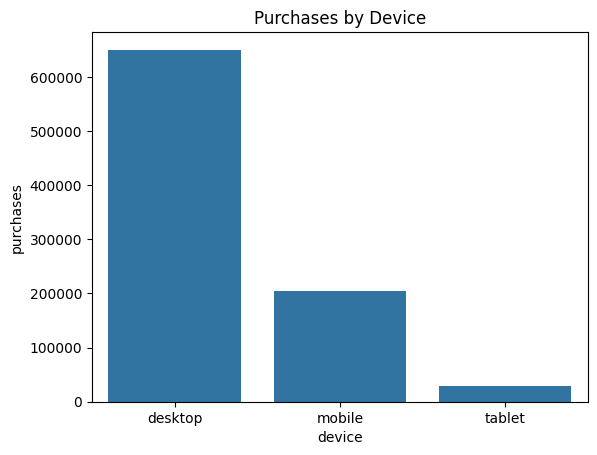

In [ ]:
# Customer Segmentation by device
device_pe = df_funnel.groupby('device').size().reset_index(name='purchases')

plt.figure()
sns.barplot(data=device_pe, x='device', y='purchases')
plt.title('Purchases by Device')
plt.show()

In [ ]:
display(device_pe)

,device,purchases
0,desktop,650277
1,mobile,204740
2,tablet,29861


In [ ]:
df_valid = df_funnel.copy()

df_valid['view_to_cart_flag'] = (
    (df_valid['product_view'] == 1) & (df_valid['add_to_cart'] == 1)
)

df_valid['cart_flag'] = df_valid['add_to_cart'] == 1

df_valid['cart_to_checkout_flag'] = (
    (df_valid['add_to_cart'] == 1) & (df_valid['checkout'] == 1)
)

df_valid['checkout_flag'] = df_valid['checkout'] == 1

df_valid['checkout_to_purchase_flag'] = (
    (df_valid['checkout'] == 1) & (df_valid['purchase'] == 1)
)

In [ ]:
# Conversion Rate Funnel by Device
funnel_device = df_valid.groupby('device').agg({
    'view_to_cart_flag': 'sum',
    'product_view': 'sum',
    'cart_to_checkout_flag': 'sum',
    'cart_flag': 'sum',
    'checkout_to_purchase_flag': 'sum',
    'checkout_flag': 'sum'
})

# Calculate conversion rates directly using the aggregated sums for each device
# Handle potential division by zero by replacing 0 with NaN in denominators
view_to_cart_device = funnel_device['view_to_cart_flag'] / funnel_device['product_view']
cart_to_checkout_device = funnel_device['cart_to_checkout_flag'] / funnel_device['cart_flag']
checkout_to_purchase_device = funnel_device['checkout_to_purchase_flag'] / funnel_device['checkout_flag']

print("Conversion Rate (Product View to Add to Cart):")
print(view_to_cart_device.apply(lambda x: f"{x:.2%}").fillna('N/A')) # Use fillna to handle cases where division by zero occurred
print("\nConversion Rate (Add to Cart to Checkout):")
print(cart_to_checkout_device.apply(lambda x: f"{x:.2%}").fillna('N/A'))
print("\nConversion Rate (Checkout to Purchase):")
print(checkout_to_purchase_device.apply(lambda x: f"{x:.2%}").fillna('N/A'))

Conversion Rate (Product View to Add to Cart):
device
desktop    38.31%
mobile     28.14%
tablet     29.87%
dtype: object

Conversion Rate (Add to Cart to Checkout):
device
desktop    41.29%
mobile     25.86%
tablet     25.52%
dtype: object

Conversion Rate (Checkout to Purchase):
device
desktop    54.41%
mobile     32.83%
tablet     43.67%
dtype: object


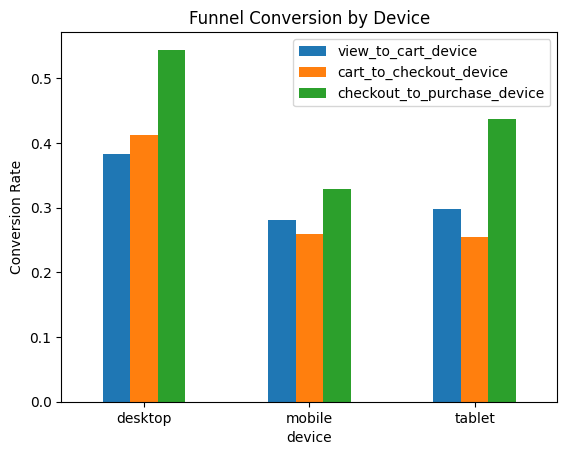

In [ ]:
funnel_device['view_to_cart_device'] = view_to_cart_device
funnel_device['cart_to_checkout_device'] = cart_to_checkout_device
funnel_device['checkout_to_purchase_device'] = checkout_to_purchase_device

funnel_device[['view_to_cart_device','cart_to_checkout_device','checkout_to_purchase_device']].plot(kind='bar')

plt.title("Funnel Conversion by Device")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# Analisis drop-off rate per device dapat menunjukkan apakah ada jenis perangkat tertentu yang memiliki masalah checkout.

# Calculate Drop-off Rate per Funnel Step by Device
drop_off_view_to_cart_device = 1 - view_to_cart_device
drop_off_cart_to_checkout_device = 1 - cart_to_checkout_device
drop_off_checkout_to_purchase_device = 1 - checkout_to_purchase_device

print("Drop-off Rate (Product View to Add to Cart):")
print(drop_off_view_to_cart_device.apply(lambda x: f"{x:.2%}"))
print("\nDrop-off Rate (Add to Cart to Checkout):")
print(drop_off_cart_to_checkout_device.apply(lambda x: f"{x:.2%}"))
print("\nDrop-off Rate (Checkout to Purchase):")
print(drop_off_checkout_to_purchase_device.apply(lambda x: f"{x:.2%}"))

Drop-off Rate (Product View to Add to Cart):
device
desktop    61.69%
mobile     71.86%
tablet     70.13%
dtype: object

Drop-off Rate (Add to Cart to Checkout):
device
desktop    58.71%
mobile     74.14%
tablet     74.48%
dtype: object

Drop-off Rate (Checkout to Purchase):
device
desktop    45.59%
mobile     67.17%
tablet     56.33%
dtype: object


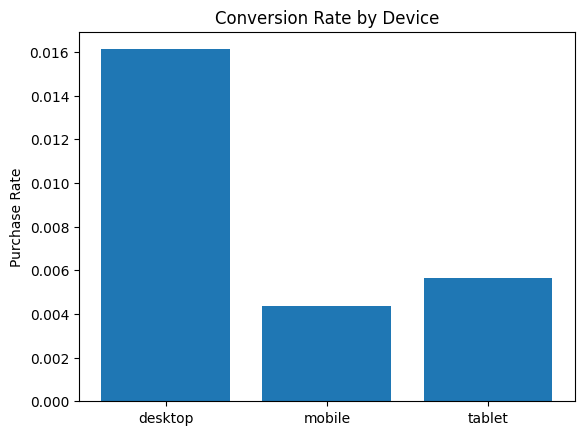

In [ ]:
# Overall Funnel Conversion Rate by Device
device_conversion = df_funnel.groupby('device')['purchase'].mean().reset_index()
device_conversion

plt.bar(device_conversion['device'], device_conversion['purchase'])
plt.title("Conversion Rate by Device")
plt.ylabel("Purchase Rate")
plt.show()

In [ ]:
df_funnel.groupby('device').apply(
    lambda x: x[x['purchase']==1]['visitId'].nunique() /
              x[x['product_view']==1]['visitId'].nunique()
)

/tmp/ipykernel_974/275780489.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_funnel.groupby('device').apply(


,0
device,
desktop,0.111289
mobile,0.034618
tablet,0.046518


In [ ]:
# Time to Purchase Analysis
first_visit = df_funnel.groupby('fullVisitorId')['visit_date'].min().reset_index()
first_visit.columns = ['fullVisitorId', 'first_visit_date']

purchase_sessions = df_funnel[df_funnel['purchase'] == 1][['fullVisitorId','visit_date']]
purchase_sessions = purchase_sessions.rename(columns={'visit_date':'purchase_date'})

purchase_time = purchase_sessions.merge(first_visit, on='fullVisitorId')

purchase_time['days_to_purchase'] = (
    purchase_time['purchase_date'] - purchase_time['first_visit_date']
).dt.days

purchase_time['days_to_purchase'].describe()

,days_to_purchase
count,11543.000000
mean,16.003379
std,39.115539
min,0.000000
25%,0.000000
50%,0.000000
75%,12.000000
max,351.000000


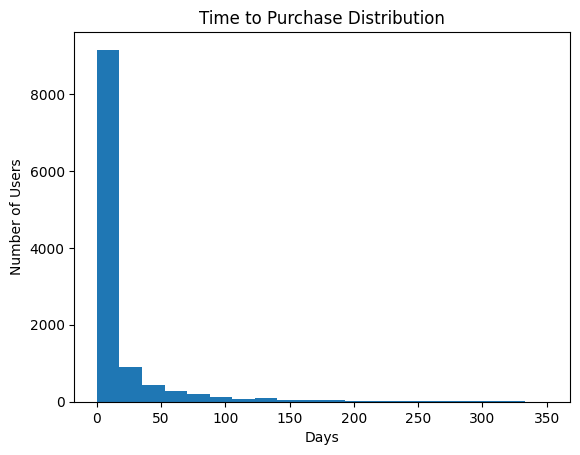

In [ ]:
plt.hist(purchase_time['days_to_purchase'], bins=20)
plt.title("Time to Purchase Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Users")
plt.show()

In [ ]:
# Traffic Source Distribution
df_funnel['traffic_source'].value_counts().head(10)

,count
traffic_source,
(direct),363301
google,236631
youtube.com,208407
Partners,16038
analytics.google.com,15723
dfa,5569
google.com,4591
m.facebook.com,3296
baidu,3238


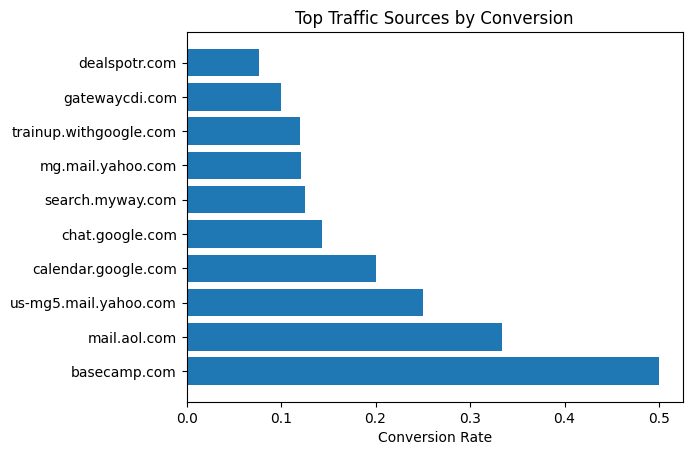

In [ ]:
# Conversion by Traffic Source
traffic_conversion = (
    df_funnel.groupby('traffic_source')['purchase']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

traffic_conversion.head(10)

plt.barh(traffic_conversion['traffic_source'][:10],
         traffic_conversion['purchase'][:10])

plt.title("Top Traffic Sources by Conversion")
plt.xlabel("Conversion Rate")
plt.show()

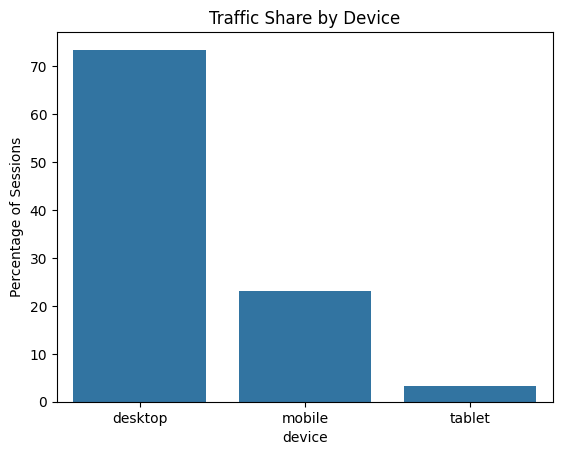

In [ ]:
# Traffic Share
device_traffic = df_funnel['device'].value_counts(normalize=True) * 100
device_traffic_df = device_traffic.reset_index()
device_traffic_df.columns = ['device','traffic_share']

sns.barplot(data=device_traffic_df, x='device', y='traffic_share')
plt.title("Traffic Share by Device")
plt.ylabel("Percentage of Sessions")
plt.show()

In [ ]:
# Funnel by Country
funnel_country = df_valid.groupby('country').agg({
    'view_to_cart_flag': 'sum',
    'product_view': 'sum',
    'cart_to_checkout_flag': 'sum',
    'cart_flag': 'sum',
    'checkout_to_purchase_flag': 'sum',
    'checkout_flag': 'sum'
})

# filter meaningful data
threshold = funnel_country['product_view'].quantile(0.75)
print(f"Threshold value (75th percentile of product views): {threshold:.2f}")

funnel_country_filtered = funnel_country[
    funnel_country['product_view'] > threshold
]
print(funnel_country_filtered)

Threshold value (75th percentile of product views): 123.00
                      view_to_cart_flag  product_view  cart_to_checkout_flag  \
country                                                                        
Argentina                           101           351                     20   
Australia                           544          1587                    149   
Austria                              74           248                     27   
Bangladesh                           36           145                      7   
Belgium                             169           445                     50   
Brazil                              343          1033                     85   
Canada                             2126          5289                    715   
Chile                                48           170                     18   
China                                65           223                     25   
Colombia                            102           428        

In [ ]:
# safe division
view_to_cart_country = funnel_country_filtered['view_to_cart_flag'] / funnel_country_filtered['product_view']
cart_to_checkout_country = funnel_country_filtered['cart_to_checkout_flag'] / funnel_country_filtered['cart_flag']
checkout_to_purchase_country = funnel_country_filtered['checkout_to_purchase_flag'] / funnel_country_filtered['checkout_flag']

print("Top Countries by View → Cart")
display(view_to_cart_country.dropna().sort_values(ascending=False).head(5))

print("\nTop Countries by Cart → Checkout")
display(cart_to_checkout_country.dropna().sort_values(ascending=False).head(5))

print("\nTop Countries by Checkout → Purchase")
display(checkout_to_purchase_country.dropna().sort_values(ascending=False).head(5))

Top Countries by View → Cart


,0
country,
Venezuela,0.629969
Romania,0.44557
Canada,0.401966
Belgium,0.379775
United States,0.37973



Top Countries by Cart → Checkout


,0
country,
Venezuela,0.718894
United States,0.439695
Sri Lanka,0.364706
Indonesia,0.356021
Chile,0.346154



Top Countries by Checkout → Purchase


,0
country,
United States,0.640593
Venezuela,0.356725
Argentina,0.26087
Egypt,0.25
Canada,0.239558


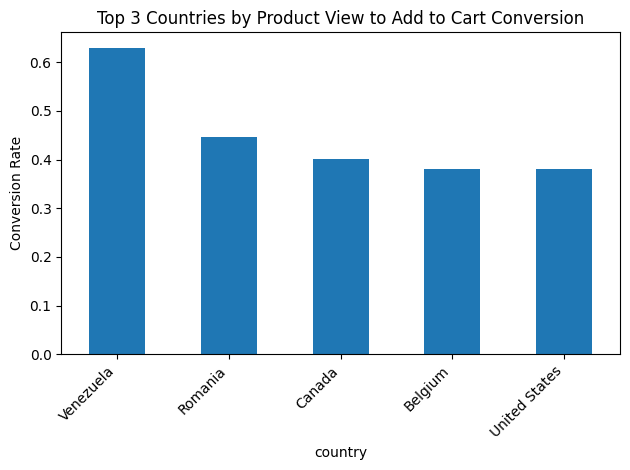

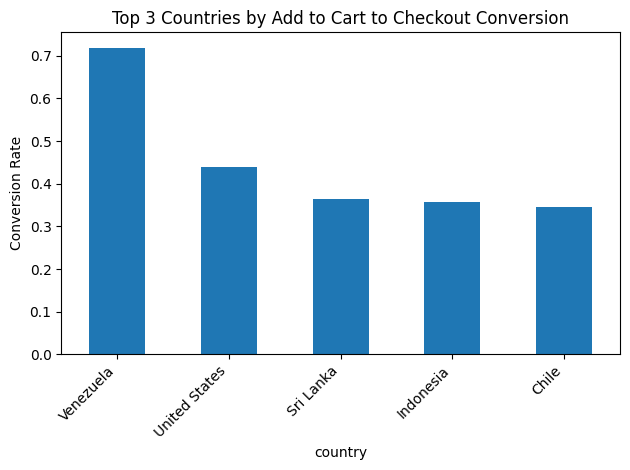

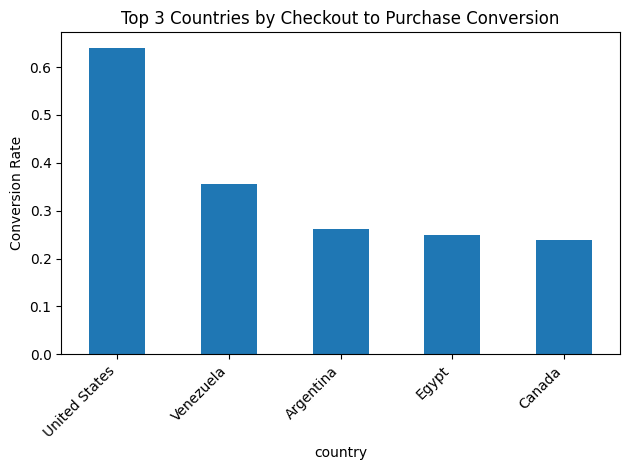

In [ ]:
# Top 3 countries by 'view_to_cart' conversion
top_3_view_to_cart = view_to_cart_country.sort_values(ascending=False).head(5)
top_3_view_to_cart.plot(kind='bar')
plt.title("Top 3 Countries by Product View to Add to Cart Conversion")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top 3 countries by 'cart_to_checkout' conversion
top_3_cart_to_checkout = cart_to_checkout_country.sort_values(ascending=False).head(5)
top_3_cart_to_checkout.plot(kind='bar')
plt.title("Top 3 Countries by Add to Cart to Checkout Conversion")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top 3 countries by 'checkout_to_purchase' conversion
top_3_checkout_to_purchase = checkout_to_purchase_country.sort_values(ascending=False).head(5)
top_3_checkout_to_purchase.plot(kind='bar')
plt.title("Top 3 Countries by Checkout to Purchase Conversion")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Mungkin ada masalah pembayaran atau pengiriman di wilayah tertentu.

# Calculate Drop-off Rate per Funnel Step by Country
drop_off_view_to_cart_country = 1 - view_to_cart_country
drop_off_cart_to_checkout_country = 1 - cart_to_checkout_country
drop_off_checkout_to_purchase_country = 1 - checkout_to_purchase_country

print("Drop-off Rate (Product View to Add to Cart):")
print(drop_off_view_to_cart_country.sort_values(ascending=False).head(5).apply(lambda x: f"{x:.2%}"))
print("\nDrop-off Rate (Add to Cart to Checkout):")
print(drop_off_cart_to_checkout_country.sort_values(ascending=False).head(5).apply(lambda x: f"{x:.2%}"))
print("\nDrop-off Rate (Checkout to Purchase):")
print(drop_off_checkout_to_purchase_country.sort_values(ascending=False).head(5).apply(lambda x: f"{x:.2%}"))

Drop-off Rate (Product View to Add to Cart):
country
Thailand       76.87%
Philippines    76.41%
Colombia       76.17%
Bangladesh     75.17%
Egypt          74.13%
dtype: object

Drop-off Rate (Add to Cart to Checkout):
country
Bangladesh      86.00%
Greece          85.11%
South Africa    84.21%
Egypt           84.09%
Romania         83.60%
dtype: object

Drop-off Rate (Checkout to Purchase):
country
Slovakia     100.00%
Norway       100.00%
India         97.58%
Italy         97.41%
Sri Lanka     97.14%
dtype: object




> **Product Performance Analysis**



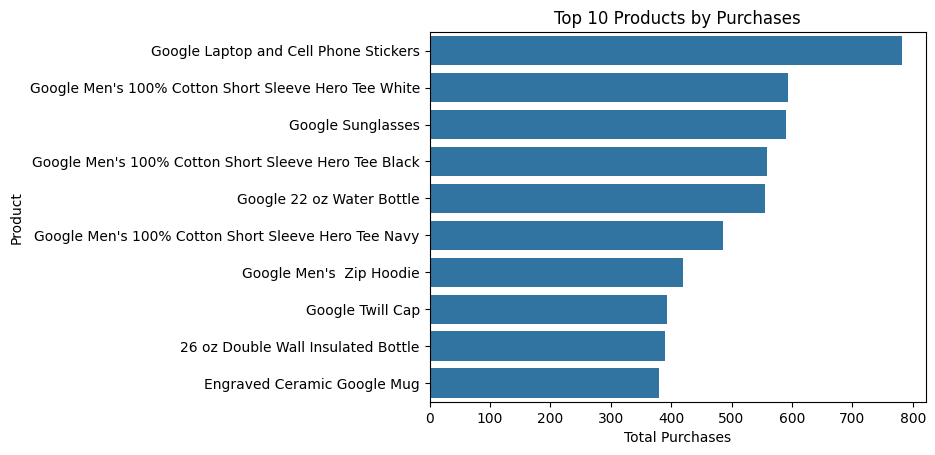

In [ ]:
# Top Product by Purchase
top_products = (
    df_product_perf.groupby('product_name')
      .agg(
          total_purchases=('visitId', 'count'),
          unique_buyers=('fullVisitorId', 'nunique')
      )
      .sort_values('total_purchases', ascending=False)
      .head(10)
)

plt.figure()
sns.barplot(data=top_products, x='total_purchases', y=top_products.index)
plt.title('Top 10 Products by Purchases')
plt.xlabel('Total Purchases')
plt.ylabel('Product')
plt.show()

In [ ]:
# Broad Product vs Repeat-heavy Product Analysis
product_behavior = (
    df_product_perf.groupby('product_name')
    .agg(
        total_purchases=('visitId', 'count'),
        unique_buyers=('fullVisitorId', 'nunique')
    )
)

# rasio repeat
product_behavior['repeat_ratio'] = (
    product_behavior['total_purchases'] / product_behavior['unique_buyers']
)

product_behavior.sort_values('repeat_ratio', ascending=False).head(10)

,total_purchases,unique_buyers,repeat_ratio
product_name,,,
YouTube Women's S/S Crew Tee,5,3,1.666667
Google Women's Badge Performance Tee Black,3,2,1.5
Aria Bluetooth Speaker,11,8,1.375
Pop-a-Point Crayon,9,7,1.285714
Ballpoint Pen Blue,153,121,1.264463
Retractable Ballpoint Pen Red,76,62,1.225806
Google Men's 3/4 Sleeve Raglan Henley Grey,17,14,1.214286
Galaxy Screen Cleaning Cloth,167,138,1.210145
Oasis Backpack,6,5,1.2


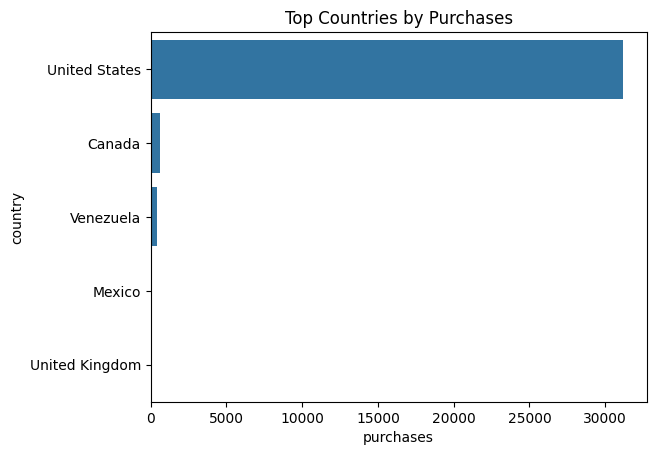

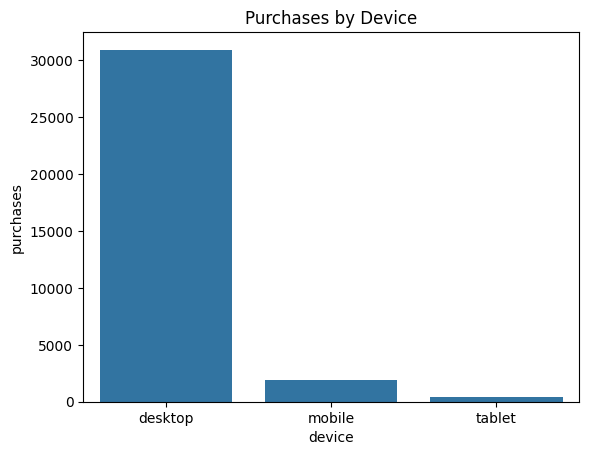

In [ ]:
# Customer Segmentation by Country
country_perf = (
    df_product_perf.groupby('country')
      .agg(purchases=('visitId', 'count'))
      .sort_values('purchases', ascending=False)
      .head(5)
)

plt.figure()
sns.barplot(data=country_perf, x='purchases', y=country_perf.index)
plt.title('Top Countries by Purchases')
plt.show()

In [ ]:
# Hitung frekuensi setiap 'num_products'
num_products_distribution = prod_per_session['num_products'].value_counts().reset_index()
num_products_distribution.columns = ['num_products', 'count_visits']

# Urutkan berdasarkan 'count_visits' terbanyak (descending)
num_products_distribution_sorted = num_products_distribution.sort_values(by='count_visits', ascending=False)

print("Distribusi Jumlah Produk per Sesi (Diurutkan berdasarkan Jumlah Kunjungan):")
display(num_products_distribution_sorted)

Distribusi Jumlah Produk per Sesi (Diurutkan berdasarkan Jumlah Kunjungan):


,num_products,count_visits
0,1,4528
1,2,2486
2,3,1538
3,4,982
4,5,625
5,6,410
6,7,274
7,8,188
8,9,136
9,10,101


In [ ]:
# Product Basket/Diversity
prod_per_session = (
    df_product_perf.groupby('visitId')['product_name']
      .nunique()
      .reset_index(name='num_products')
)

plt.figure()
sns.histplot(prod_per_session['num_products'], bins=20)
plt.title('Distribution of Products per Session')
plt.xlabel('Number of Products')
plt.show()

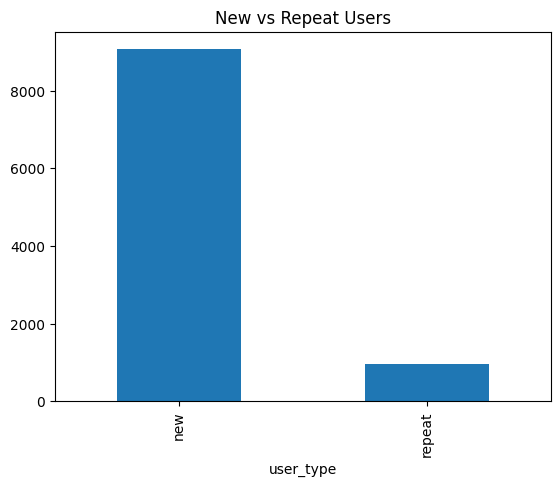

In [ ]:
# Repeat vs New User
user_sessions = (
    df_product_perf.groupby('fullVisitorId')['visitId']
      .nunique()
      .reset_index(name='num_sessions')
)

user_sessions['user_type'] = user_sessions['num_sessions'].apply(
    lambda x: 'repeat' if x > 1 else 'new'
)

user_type_dist = user_sessions['user_type'].value_counts()

plt.figure()
user_type_dist.plot(kind='bar')
plt.title('New vs Repeat Users')
plt.show()

In [ ]:
# Repeat vs New User
user_sessions = (
    df_product_perf.groupby('fullVisitorId')['visitId']
      .nunique()
      .reset_index(name='num_sessions')
)

user_sessions['user_type'] = user_sessions['num_sessions'].apply(
    lambda x: 'repeat' if x > 1 else 'new'
)

user_type_dist = user_sessions['user_type'].value_counts()
user_type_dist

,count
user_type,
new,9066
repeat,970


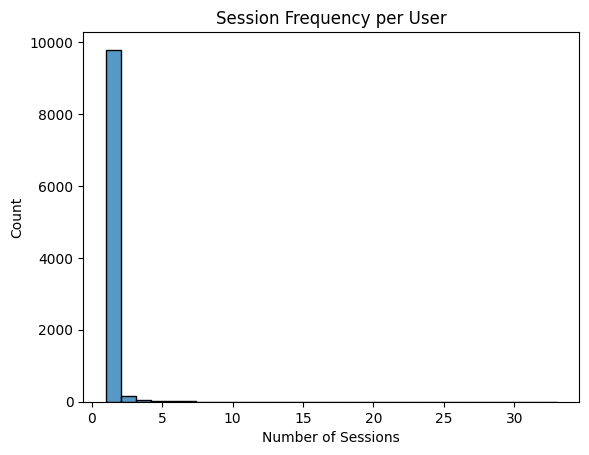

In [ ]:
# Session Frequency
plt.figure()
sns.histplot(user_sessions['num_sessions'], bins=30)
plt.title('Session Frequency per User')
plt.xlabel('Number of Sessions')
plt.show()

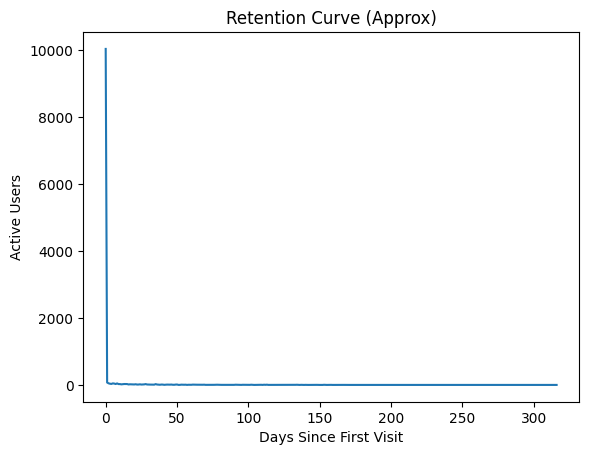

In [ ]:
# Retention
df_product_perf['visit_date'] = pd.to_datetime(df_product_perf['visit_date'])

first_seen = df_product_perf.groupby('fullVisitorId')['visit_date'].min().reset_index()
first_seen.columns = ['fullVisitorId', 'first_date']

df_ret = df_product_perf.merge(first_seen, on='fullVisitorId')

df_ret['days_since_first'] = (df_ret['visit_date'] - df_ret['first_date']).dt.days

retention = df_ret.groupby('days_since_first')['fullVisitorId'].nunique()

plt.figure()
retention.plot()
plt.title('Retention Curve (Approx)')
plt.xlabel('Days Since First Visit')
plt.ylabel('Active Users')
plt.show()



> **Product Summary Analysis**



In [ ]:
# Top Viewed vs Top Purchased
top_viewed = df_product_sc.sort_values('product_view', ascending=False).head(5)
top_purchased = df_product_sc.sort_values('purchase', ascending=False).head(5)

print("Top Viewed Products")
display(top_viewed)

print("Top Purchased Products")
display(top_purchased)

Top Viewed Products


,product_name,total_sessions,product_view,add_to_cart,checkout,purchase
537,Google Men's 100% Cotton Short Sleeve Hero Tee...,168011,8024,3110,1155,593
432,Google Alpine Style Backpack,77626,5829,789,249,93
469,Waterproof Backpack,76137,5567,688,281,129
532,Google Men's Zip Hoodie,87860,5087,1548,695,420
538,Google Laptop and Cell Phone Stickers,77073,5007,3144,1536,782


Top Purchased Products


,product_name,total_sessions,product_view,add_to_cart,checkout,purchase
538,Google Laptop and Cell Phone Stickers,77073,5007,3144,1536,782
537,Google Men's 100% Cotton Short Sleeve Hero Tee...,168011,8024,3110,1155,593
536,Google Sunglasses,41125,3304,1552,966,590
535,Google Men's 100% Cotton Short Sleeve Hero Tee...,111833,3099,1554,884,559
534,Google 22 oz Water Bottle,32609,1391,1088,878,556


In [ ]:
threshold = df_product_sf['product_view'].quantile(0.75)
df_filtered = df_product_sf[
    (df_product_sf['product_view'] > threshold) &
    (df_product_sf['checkout'] > 20)
]

In [ ]:
# Conversion per Product
Overall_conversion = df_filtered.sort_values('overall_conversion_rate', ascending=False).head(5)
print("Overall Conversion Rate")
display(Overall_conversion)

Overall Conversion Rate


,product_name,product_view,add_to_cart,checkout,purchase,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,overall_conversion_rate
399,Google Baby Essentials Set,605,376,293,211,0.571901,0.571809,0.720137,0.233058
398,Four Color Retractable Pen,713,467,289,198,0.619916,0.516060,0.685121,0.221599
422,Foam Can and Bottle Cooler,904,556,435,302,0.523230,0.543165,0.694253,0.207965
441,Google 22 oz Water Bottle,1391,1088,878,556,0.638390,0.520221,0.633257,0.207045
429,Maze Pen,1412,917,492,324,0.591360,0.486369,0.658537,0.194759


In [ ]:
# Drop off Analysis (Find Problematic Product)
low_conversion = df_filtered[
    (df_filtered['product_view'] > 100) &
    (df_filtered['view_to_cart_rate'] < 0.1)
].sort_values('product_view', ascending=False).head(5)

print("Products with high views but low conversion")
display(low_conversion)

Products with high views but low conversion


,product_name,product_view,add_to_cart,checkout,purchase,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,overall_conversion_rate
258,25L Classic Rucksack,1750,209,76,43,0.096000,0.354067,0.565789,0.016571
207,"Google High Capacity 10,400mAh Charger",1147,130,54,32,0.097646,0.369231,0.592593,0.021796
150,YouTube RFID Journal,1037,114,36,20,0.087753,0.271930,0.555556,0.011572
156,Google Bluetooth Speaker-Power Bank,977,104,40,18,0.093142,0.365385,0.450000,0.018424
113,Google Flashlight,907,59,22,13,0.058434,0.254237,0.590909,0.011025


In [ ]:
products_low_conversion = low_conversion.copy()

# Calculate drop-off rates for each step
products_low_conversion['drop_off_view_to_cart'] = 1 - products_low_conversion['view_to_cart_rate']
products_low_conversion['drop_off_cart_to_checkout'] = 1 - products_low_conversion['cart_to_checkout_rate']
products_low_conversion['drop_off_checkout_to_purchase'] = 1 - products_low_conversion['checkout_to_purchase_rate']

print("Drop-off Rates for Products with High Views but Low Conversion:")
display(products_low_conversion[['product_name', 'drop_off_view_to_cart', 'drop_off_cart_to_checkout', 'drop_off_checkout_to_purchase']].round(4) * 100)

Drop-off Rates for Products with High Views but Low Conversion:


,product_name,drop_off_view_to_cart,drop_off_cart_to_checkout,drop_off_checkout_to_purchase
258,25L Classic Rucksack25L Classic Rucksack25L Cl...,90.40,64.59,43.42
207,"Google High Capacity 10,400mAh ChargerGoogle H...",90.24,63.08,40.74
150,YouTube RFID JournalYouTube RFID JournalYouTub...,91.22,72.81,44.44
156,Google Bluetooth Speaker-Power BankGoogle Blue...,90.69,63.46,55.00
113,Google FlashlightGoogle FlashlightGoogle Flash...,94.16,74.58,40.91


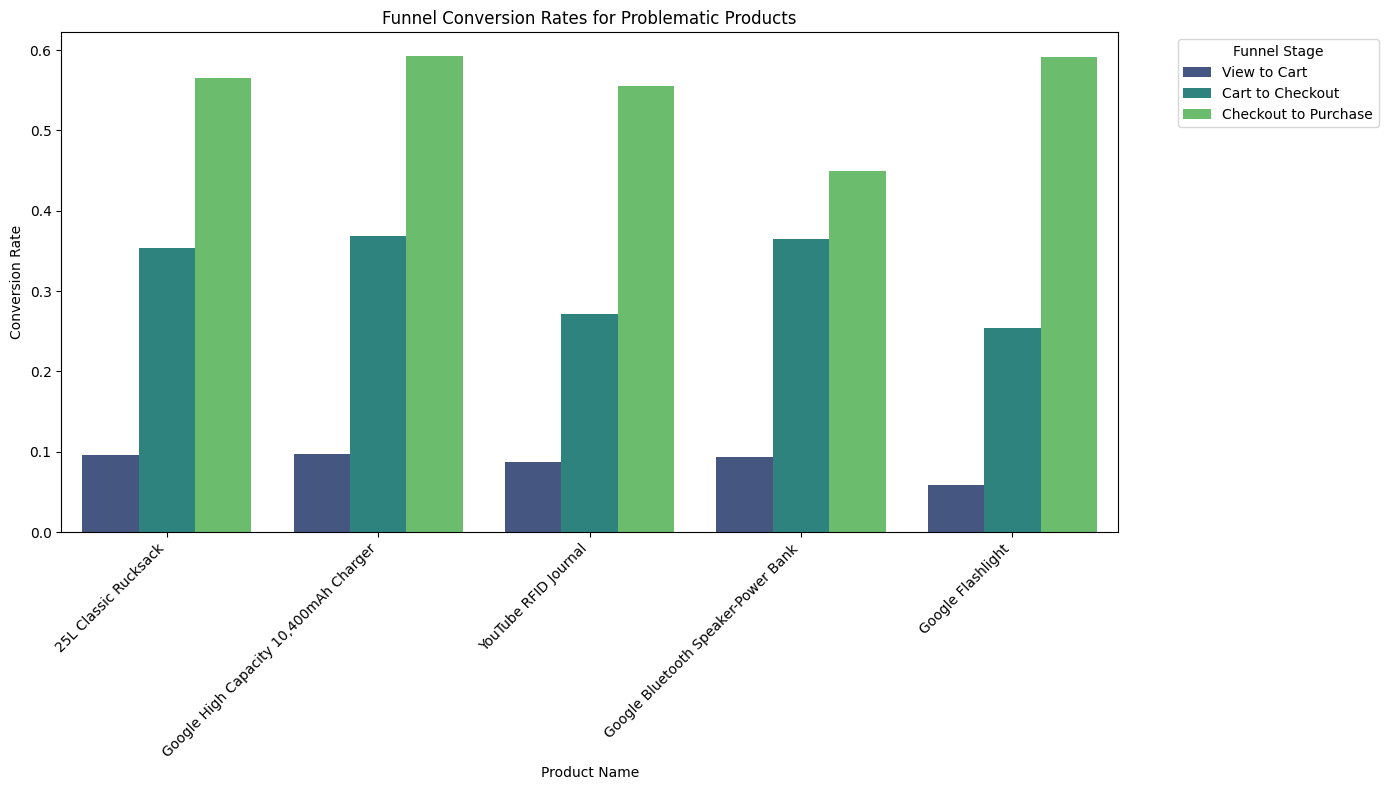

In [ ]:
# Select relevant columns for the funnel rates from the low_conversion DataFrame
funnel_rates_data = products_low_conversion[['product_name', 'view_to_cart_rate', 'cart_to_checkout_rate', 'checkout_to_purchase_rate']]

# Melt the DataFrame to long format for easier plotting with seaborn
funnel_rates_melted = funnel_rates_data.melt(
    id_vars=['product_name'],
    var_name='Funnel Stage',
    value_name='Conversion Rate'
)

# Map the stage names for better readability on the plot
stage_name_mapping = {
    'view_to_cart_rate': 'View to Cart',
    'cart_to_checkout_rate': 'Cart to Checkout',
    'checkout_to_purchase_rate': 'Checkout to Purchase'
}
funnel_rates_melted['Funnel Stage'] = funnel_rates_melted['Funnel Stage'].map(stage_name_mapping)

plt.figure(figsize=(14, 8))
sns.barplot(
    x='product_name',
    y='Conversion Rate',
    hue='Funnel Stage',
    data=funnel_rates_melted,
    palette='viridis'
)

plt.title('Funnel Conversion Rates for Problematic Products')
plt.xlabel('Product Name')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Funnel Stage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
threshold = df_product_sf['product_view'].quantile(0.75)
df_filtered2 = df_product_sf[df_product_sf['product_view'] > threshold]

In [ ]:
# High Intent but No Purchase
cart_no_purchase = df_filtered2[
    (df_filtered2['add_to_cart'] > 50) &
    (df_filtered2['purchase'] == 0)
]

display(cart_no_purchase.sort_values('add_to_cart', ascending=False).head(5))

,product_name,product_view,add_to_cart,checkout,purchase,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,overall_conversion_rate
5,Google Women's 3/4 Sleeve Baseball Raglan Heat...,664,309,0,0,0.399096,0.0,NaN,0.0
14,Google Men's Weatherblock Shell Jacket Black,931,202,0,0,0.119227,0.0,NaN,0.0
0,Google Collapsible Duffel,569,167,0,0,0.226714,0.0,NaN,0.0
9,Google Women's Performance Full Zip Jacket Black,606,165,0,0,0.160066,0.0,NaN,0.0
7,Yoga Mat,631,157,0,0,0.213946,0.0,NaN,0.0


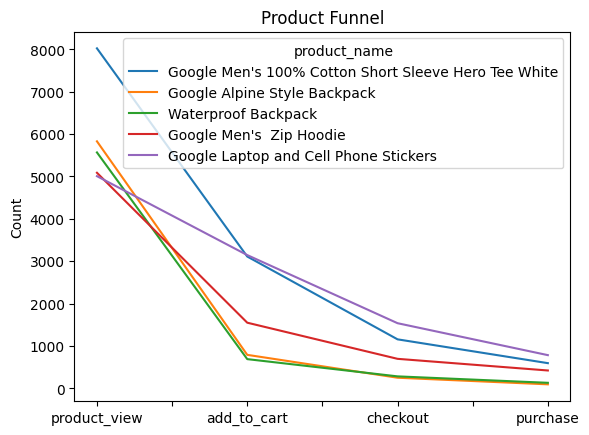

In [ ]:
# Funnel Visualization per Product
import matplotlib.pyplot as plt

top_products = df_product_sc.sort_values('product_view', ascending=False).head(5)

top_products.set_index('product_name')[[
    'product_view','add_to_cart','checkout','purchase'
]].T.plot()

plt.title("Product Funnel")
plt.ylabel("Count")
plt.show()